#End-to-End Data Analysis and Prediction

In [21]:
from google.colab import files
uploaded=files.upload()

Saving 1775223455988_ac4d264acc.csv to 1775223455988_ac4d264acc (1).csv


Imported the files into google.colab

In [3]:
import pandas as pd
df=pd.read_csv("1775223455988_ac4d264acc.csv")
df.head(25)

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78
5,2024-12-10,UK,Manchester,Groceries,Chairs,Corporate,Offline,Cash,2169.63,3,0.19,421.31
6,2022-01-29,USA,Chicago,Electronics,Fitness,Corporate,Offline,Cash,2669.29,13,0.15,994.03
7,2023-10-05,USA,New York,Sports,Snacks,Consumer,Online,UPI,4257.16,3,0.20,1290.52
8,2023-09-15,UK,Manchester,Electronics,Cosmetics,Home Office,Offline,Card,1783.33,11,0.12,484.16
9,2022-12-28,Germany,Munich,Beauty,Shirts,Consumer,Online,UPI,2350.87,7,0.14,627.51


Reading the first 25 rows of the data. We have the Order-Date, Countries, Cities, Categories of Sales and Profits.

In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     1600 non-null   object 
 1   Country        1600 non-null   object 
 2   City           1600 non-null   object 
 3   Category       1600 non-null   object 
 4   Sub_Category   1600 non-null   object 
 5   Segment        1600 non-null   object 
 6   Sales_Channel  1600 non-null   object 
 7   Payment_Mode   1600 non-null   object 
 8   Sales          1600 non-null   float64
 9   Quantity       1600 non-null   int64  
 10  Discount       1600 non-null   float64
 11  Profit         1600 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 150.1+ KB


This shows there are 1600 entries, with 12 columns and no missing values seeing they all are showing 1600 non-null. Discount,Sales and Profit have decimals in the numbers, which would mean they are floats. Quanity is the only integer with whole numbers.

In [22]:
df.isnull().sum()
df["Sales"].fillna(df["Sales"].mean(),inplace=True)
df.isnull().sum()

,0
Order_Date,0
Country,0
City,0
Category,0
Sub_Category,0
Segment,0
Sales_Channel,0
Payment_Mode,0
Sales,0
Quantity,0


Didnt need to do this because there were none, but to show how to fill missing values.

In [23]:
df["Category"].fillna("Unknown",inplace=True)
df.isnull().sum()
df.head()

/tmp/ipykernel_6043/2609160043.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Category"].fillna("Unknown",inplace=True)


,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78


Again didnt need to fill in any missing values. But if there were any we changed it to "Unknown"

In [24]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

There are no duplicates.

In [25]:
df["Category"]=df["Category"].astype("category")

In [26]:
df["Profit_Margin"]=df["Profit"]/df["Sales"]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Order_Date     1600 non-null   object  
 1   Country        1600 non-null   object  
 2   City           1600 non-null   object  
 3   Category       1600 non-null   category
 4   Sub_Category   1600 non-null   object  
 5   Segment        1600 non-null   object  
 6   Sales_Channel  1600 non-null   object  
 7   Payment_Mode   1600 non-null   object  
 8   Sales          1600 non-null   float64 
 9   Quantity       1600 non-null   int64   
 10  Discount       1600 non-null   float64 
 11  Profit         1600 non-null   float64 
 12  Profit_Margin  1600 non-null   float64 
dtypes: category(1), float64(4), int64(1), object(7)
memory usage: 151.9+ KB


You can now see how "Profit_Margin" was added in the categories at the end.

In [27]:
df["Sales_per_unit"]=df["Sales"]/df["Quantity"]

Changing a format and adding column "Sales_per_unit"

In [28]:
df["Sales_Category"]=df["Sales"].apply(lambda x:"High" if x>3000 else "Medium" if x>1000 else "Low")
df.head(25)

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit,Profit_Margin,Sales_per_unit,Sales_Category
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37,0.099930,232.317273,Medium
1,2023-12-05,UK,London,Sports,Phones,Home Office,Online,Net Banking,1795.27,9,0.28,-332.23,-0.185059,199.474444,Medium
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24,0.030790,455.473000,High
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70,0.019536,239.011538,High
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78,0.022211,231.787500,Medium
5,2024-12-10,UK,Manchester,Groceries,Chairs,Corporate,Offline,Cash,2169.63,3,0.19,421.31,0.194185,723.210000,Medium
6,2022-01-29,USA,Chicago,Electronics,Fitness,Corporate,Offline,Cash,2669.29,13,0.15,994.03,0.372395,205.330000,Medium
7,2023-10-05,USA,New York,Sports,Snacks,Consumer,Online,UPI,4257.16,3,0.20,1290.52,0.303141,1419.053333,High
8,2023-09-15,UK,Manchester,Electronics,Cosmetics,Home Office,Offline,Card,1783.33,11,0.12,484.16,0.271492,162.120909,Medium
9,2022-12-28,Germany,Munich,Beauty,Shirts,Consumer,Online,UPI,2350.87,7,0.14,627.51,0.266927,335.838571,Medium


Defining certain conditions, if sales are more than 3000 is high, medium is 1000, low is all else. Added "Sales_Category" High-Medium-Low.

In [29]:
df_filtered=df[df["Profit"]>0]
df_filtered.head()

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit,Profit_Margin,Sales_per_unit,Sales_Category
0,2022-06-20,UAE,Dubai,Furniture,Snacks,Consumer,Offline,UPI,2555.49,11,0.08,255.37,0.099930,232.317273,Medium
2,2022-07-05,USA,Los Angeles,Electronics,Shirts,Consumer,Offline,UPI,4554.73,10,0.13,140.24,0.030790,455.473000,High
3,2024-10-05,USA,New York,Furniture,Phones,Consumer,Online,Net Banking,3107.15,13,0.14,60.70,0.019536,239.011538,High
4,2023-07-21,USA,New York,Beauty,Fitness,Consumer,Offline,Card,2781.45,12,0.20,61.78,0.022211,231.787500,Medium
5,2024-12-10,UK,Manchester,Groceries,Chairs,Corporate,Offline,Cash,2169.63,3,0.19,421.31,0.194185,723.210000,Medium


Filtering Profit that was a loss.

In [5]:
df.tail()
df.sample(5)

,Order_Date,Country,City,Category,Sub_Category,Segment,Sales_Channel,Payment_Mode,Sales,Quantity,Discount,Profit
876,2022-11-03,Canada,Montreal,Groceries,Chairs,Consumer,Online,UPI,651.41,9,0.04,-59.06
952,2022-10-11,Australia,Sydney,Beauty,Fitness,Consumer,Online,Card,2477.68,14,0.23,284.21
374,2024-11-09,USA,Chicago,Electronics,Fitness,Home Office,Offline,Net Banking,2304.48,1,0.03,-15.15
431,2024-08-20,Germany,Hamburg,Beauty,Chairs,Corporate,Offline,Cash,4803.07,4,0.30,1150.62
123,2021-07-09,Australia,Perth,Electronics,Shirts,Corporate,Online,Net Banking,1582.99,3,0.28,200.79


Brought in a sample of the last 5 entries

In [6]:
df.describe()

,Sales,Quantity,Discount,Profit
count,1600.000000,1600.000000,1600.000000,1600.000000
mean,2527.242200,7.582500,0.147138,244.332881
std,1410.954469,3.999618,0.085156,515.339896
min,100.260000,1.000000,0.000000,-937.750000
25%,1293.730000,4.000000,0.070000,-88.145000
50%,2496.750000,8.000000,0.150000,138.665000
75%,3715.987500,11.000000,0.220000,535.817500
max,4996.120000,14.000000,0.300000,1921.420000


In [7]:
df["Category"].unique()

array(['Furniture', 'Sports', 'Electronics', 'Beauty', 'Groceries',
       'Clothing'], dtype=object)

Showing the categories

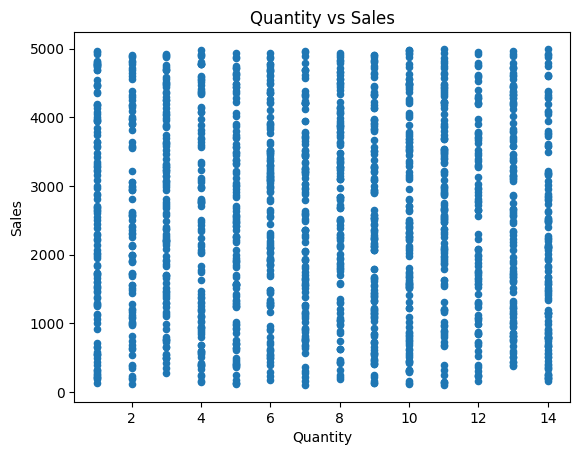

In [8]:
import matplotlib.pyplot as plt
df.plot.scatter(x="Quantity", y="Sales")
plt.title("Quantity vs Sales")
plt.show()

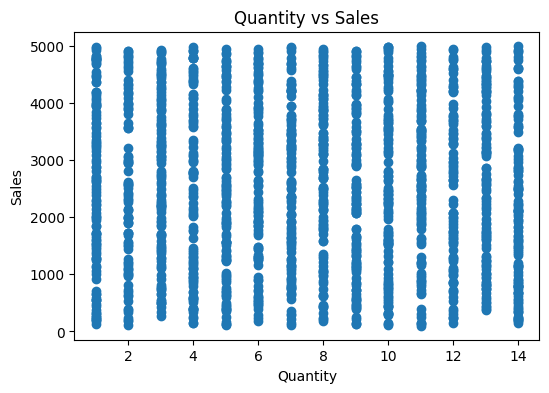

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(df["Quantity"], df["Sales"])
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

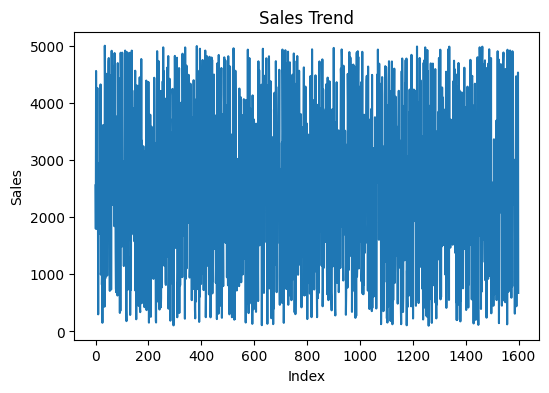

In [10]:
plt.figure(figsize=(6,4))
plt.plot(df["Sales"])
plt.title("Sales Trend")
plt.xlabel("Index")
plt.ylabel("Sales")
plt.show()

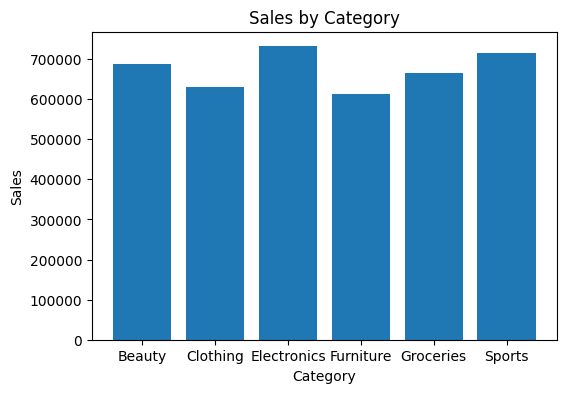

In [11]:
category_sales=df.groupby("Category")["Sales"].sum()
plt.figure(figsize=(6,4))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Electronics has the highest in sales by category.

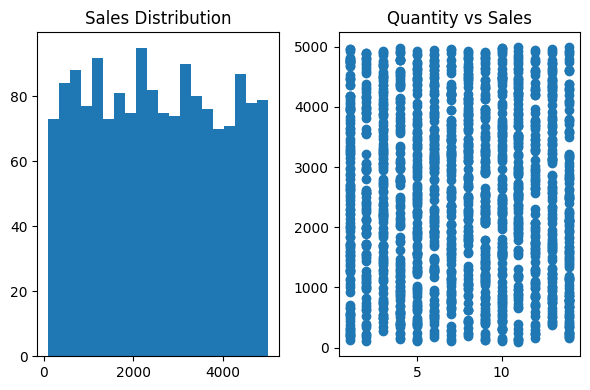

In [12]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")

plt.subplot(1,2,2)
plt.scatter(df["Quantity"], df["Sales"])
plt.title("Quantity vs Sales")

plt.tight_layout()
plt.show()

# Machine Learning

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Training and testing data using LinearRegression

In [16]:
x=df["Quantity"]
y=df["Sales"]

We are splitting both the Quantity ans Sales to train and test.

In [17]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train.values.reshape(-1,1), y_train)
predictions=model.predict(x_test.values.reshape(-1,1))
comparison=pd.DataFrame({"Actual": y_test, "Predicted": predictions})
comparison.head(10)

,Actual,Predicted
526,2516.63,2496.058837
354,4324.79,2539.555855
168,389.41,2496.058837
135,4757.41,2576.839012
937,890.72,2514.700416
1544,1074.54,2508.486557
1253,260.92,2496.058837
237,759.64,2520.914276
478,238.59,2496.058837
650,133.47,2514.700416


Created the model. Fit function to train the model. Created predictions in comparisons. Some places have a huge difference some are smaller.

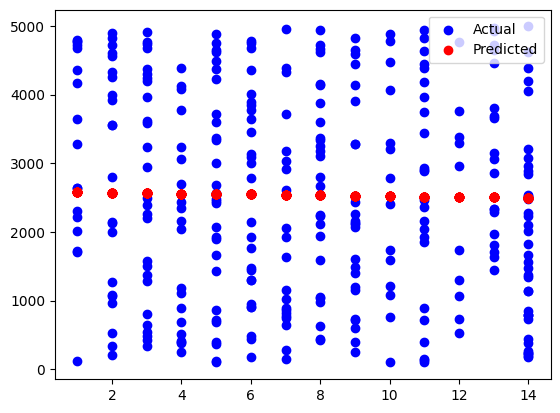

In [18]:
import matplotlib.pyplot as plt
plt.scatter(x_test, y_test, color="blue", label="Actual")
plt.scatter(x_test, predictions, color="red", label="Predicted")
plt.legend()
plt.show()

Made scatter plot to see predictions on testing data. The predictions in red are working perfectly, seeing how the red dots in linear. No dots are outside of prediction.

In [19]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train.values.reshape(-1,1), y_train)
rf_predictions=rf_model.predict(x_test.values.reshape(-1,1))
rf_comparison=pd.DataFrame({"Actual": y_test, "Predicted": rf_predictions})
rf_comparison.head(10)

,Actual,Predicted
526,2516.63,2235.521098
354,4324.79,2646.343869
168,389.41,2235.521098
135,4757.41,2436.812626
937,890.72,2792.669632
1544,1074.54,2483.541789
1253,260.92,2235.521098
237,759.64,2433.060914
478,238.59,2235.521098
650,133.47,2792.669632


Using ensemple to combine multiple models. Created another model, fit the model and predicted in RandomForestRegressor to train and test.

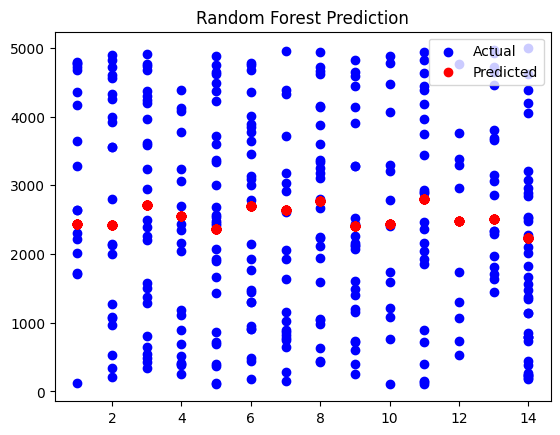

In [20]:
import matplotlib.pyplot as plt
plt.scatter(x_test, y_test, color="blue", label="Actual")
plt.scatter(x_test, rf_predictions, color="red", label="Predicted")
plt.legend()
plt.title("Random Forest Prediction")
plt.show()

You can see that the red dots are not as linear. The prediction for this model has more movement in the dots than the LinearRegresstion model.

In [30]:
df.groupby("Category")["Sales"].sum()

/tmp/ipykernel_6043/3580000923.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Category")["Sales"].sum()


,Sales
Category,
Beauty,688420.08
Clothing,630325.56
Electronics,731746.40
Furniture,612974.41
Groceries,664186.42
Sports,715934.65


Grouping the categories to see the Sales sum of each. Electronics is the highest in sales, Furniture is showing the least amount.

---



In [42]:
df.groupby("Category")["Profit"].sum()

/tmp/ipykernel_6043/452876714.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Category")["Profit"].sum()


,Profit
Category,
Beauty,59366.93
Clothing,64043.43
Electronics,64984.25
Furniture,62985.43
Groceries,57722.93
Sports,81829.64


Sports is showing the highest category in profit at 81829.64

In [41]:
df.groupby("Country")["Sales"].sum()

,Sales
Country,
Australia,532962.41
Canada,519270.73
France,489668.51
Germany,463782.57
India,573086.68
UAE,538894.26
UK,451689.82
USA,474232.54


The highest country in sales in India at 573086.68, the lowest country is showing the UK at 451689.82

In [43]:
df.groupby("Country")["Profit"].sum()

,Profit
Country,
Australia,44260.35
Canada,45124.73
France,51087.55
Germany,46524.36
India,56905.04
UAE,46844.97
UK,48235.33
USA,51950.28


In [35]:
df.to_csv("brooke_cleaned_data.csv",index=False)

Converting index to False because dont need to start at 0 in the table.

In [36]:
from google.colab import files
files.download("brooke_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Insights and Business Recommendations

**Which category performs best and why?**


- Electronics category perfprmed best because it was the highest in sales.


**Which country shows growth potential?**

- The country showing the highest in growth is India making the most in Sales but also in Profits.


**What factors influence sales the most?**
- You have many factors. We have quanitity, discounts, different categories.

**How accurate is your prediction model?**
- Two models were tested and trained. The LinearRegresstion model showed a more consistant Linear line in the scatter plot with the actual and the predictions. The second model RandomForestRegresstion showed a less consistant line than Linear showed. There were more movement of the red dots outside the data.


**What business recommendations would you give?**
- Business recommendation i would give would be use India data to see what differences there are with the lowest country of sales. Factor the differences in and try that and see if sales and profit rises. Different countries could do better in different categories than others. For example sports are not going to be the same in every country. Look for your weaknesses and strengths for the countries. See whats tredning and what is not.

Imported the new cleaned csv file